 ## 実践編

 ## 今のデータ

In [3]:
import pandas as pd

# 学習データ
data = {
    "耳の長さ": [5, 6, 2, 3],
    "体重": [1.5, 1.7, 0.9, 1.0],
    "種類": ["ウサギ", "ウサギ", "モル", "モル"]
}

df = pd.DataFrame(data)

# 新入り
new_animal = pd.DataFrame({
    "耳の長さ": [4],
    "体重": [1.2],
    "種類": ["←新入り"]
})

# 結合
display_df = pd.concat([df, new_animal], ignore_index=True)

display_df

,耳の長さ,体重,種類
0,5,1.5,ウサギ
1,6,1.7,ウサギ
2,2,0.9,モル
3,3,1.0,モル
4,4,1.2,←新入り


In [5]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 85.3 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 163.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 215.1 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
%pip install matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 散布図

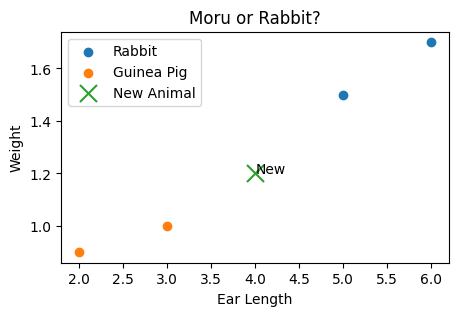

In [11]:
import matplotlib.pyplot as plt

# ウサギだけ
rabbit = df[df["種類"] == "ウサギ"]

# モルだけ
moru = df[df["種類"] == "モル"]

plt.figure(figsize=(5, 3))

# ウサギ
plt.scatter(
    rabbit["耳の長さ"],
    rabbit["体重"],
    label="Rabbit"
)

# モル
plt.scatter(
    moru["耳の長さ"],
    moru["体重"],
    label="Guinea Pig"
)

# 新入り
plt.scatter(
    new_animal["耳の長さ"],
    new_animal["体重"],
    label="New Animal",
    marker="x",
    s=150
)

plt.annotate(
    "New",
    (4, 1.2)
)

plt.xlabel("Ear Length")
plt.ylabel("Weight")
plt.title("Moru or Rabbit?")
plt.legend()
plt.grid(False)

plt.show()

## 距離を計算する

新入り(4, 1.2)から各動物までの距離を求める。

## 高校数学の距離公式  
$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$  

<div align="left">
    <img src="images/C_EuclideanDistance.png" width="500">
</div>
  
#### 新入り $(4,1.2)$ とモル① $(3,1.0)$ の距離は

$d=\sqrt{(4-3)^2+(1.2-1.0)^2}$

で求める。

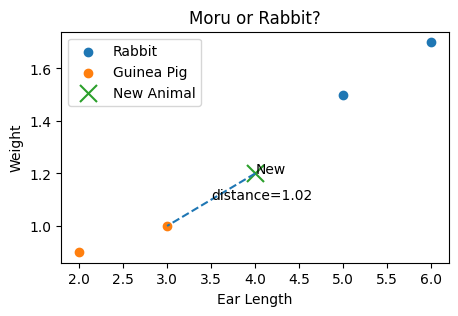

In [18]:
import matplotlib.pyplot as plt

# ウサギだけ
rabbit = df[df["種類"] == "ウサギ"]

# モルだけ
moru = df[df["種類"] == "モル"]

plt.figure(figsize=(5, 3))

# ウサギ
plt.scatter(
    rabbit["耳の長さ"],
    rabbit["体重"],
    label="Rabbit"
)

# モル
plt.scatter(
    moru["耳の長さ"],
    moru["体重"],
    label="Guinea Pig"
)

# 新入り
plt.scatter(
    new_animal["耳の長さ"],
    new_animal["体重"],
    label="New Animal",
    marker="x",
    s=150
)

plt.annotate(
    "New",
    (4, 1.2)
)

plt.plot(
    [4, 3],
    [1.2, 1.0],
    linestyle="--"
)

plt.annotate(
    "distance=1.02",
    (3.5, 1.1)
)

plt.xlabel("Ear Length")
plt.ylabel("Weight")
plt.title("Moru or Rabbit?")
plt.legend()
plt.grid(False)

plt.show()

散布図を見ると、新入り(4,1.2)はモルとウサギの中間に位置している。
そのため、どちらに分類されるか距離を計算して確認する。

## 距離計算

K-NNでは新入りと既存データとの距離を計算する。

距離が近いほど特徴が似ていると考える。

今回はユークリッド距離を使用する。

例えば  
モル①  
(3, 1.0)  
なら

In [12]:
import numpy as np

distance = np.sqrt(
    (4 - 3)**2 +
    (1.2 - 1.0)**2
)

distance

np.float64(1.019803902718557)

In [19]:
import numpy as np

for index, row in df.iterrows():

    distance = np.sqrt(
        (new_animal["耳の長さ"][0] - row["耳の長さ"])**2 +
        (new_animal["体重"][0] - row["体重"])**2
    )

    print(
        row["種類"],
        "距離:",
        round(distance, 3)
    )

ウサギ 距離: 1.044
ウサギ 距離: 2.062
モル 距離: 2.022
モル 距離: 1.02


### 近い順に並べる

In [22]:
distances = []

for index, row in df.iterrows():

    distance = np.sqrt(
        (new_animal["耳の長さ"][0] - row["耳の長さ"])**2 +
        (new_animal["体重"][0] - row["体重"])**2
    )

    distances.append(
        [row["種類"], distance]
    )

sorted(distances, key=lambda x: x[1])

[['モル', np.float64(1.019803902718557)],
 ['ウサギ', np.float64(1.044030650891055)],
 ['モル', np.float64(2.0223748416156684)],
 ['ウサギ', np.float64(2.0615528128088303)]]

## K=1

最も近い1匹だけを見て判定する。

## 結果

モルモット

## K=3

近い3匹で多数決を行う。

### 近い3匹

モルモット
ウサギ
モルモット

### 投票結果

モルモット 2票
ウサギ     1票  
↓
### 判定：モルモット


## k-NNまとめ

散布図を書く  
↓  
距離公式  
↓  
全員との距離計算  
↓  
近い順に並べる  
↓  
K=1  
↓  
K=3  



## KNNの弱点

KNNは新入りと既存データの距離を計算して分類する。

しかし、データ数が増えると毎回すべての距離を計算する必要があり、
処理が重くなる。

また、どこからウサギでどこからモルなのかという
明確な基準は持っていない。